# Test — Frame Potential sur un circuit simple
Ce notebook teste le calcul du frame potential sur des circuits élémentaires pour vérifier que tout fonctionne avant de passer à des ansätze plus complexes.

In [1]:
# ── Installations (décommenter si besoin) ──────────────────────────────────
# !pip install qiskit qiskit-aer numpy scipy tqdm matplotlib

In [2]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Operator

# Fonctions du script principal
from frame_potential import (
    sample_unitary,
    sample_unitaries,
    frame_potential,
    haar_frame_potential,
    compute_frame_potential,
    sweep_t,
)

from circuit_generation import build_ansatz

print("Imports OK ✓")

Imports OK ✓


---
## 1 — Circuit de référence : identité (1 qubit, 0 paramètre)

Un circuit identité ne génère qu'**une seule** unitaire (la matrice identité).  
Le frame potential doit donc valoir exactement **1** pour tout t, puisque :

$$F^{(t)} = \frac{1}{N^2}\sum_{i,j} |\mathrm{Tr}(U_i^\dagger U_j)|^{2t} = |\mathrm{Tr}(I)|^{2t} = d^{2t}$$

avec $d=2$ pour 1 qubit, mais normalisé par $d^{2t}$ dans notre formule → **ratio F/F_Haar très grand** (pire cas expressibilité).

In [4]:
# Circuit identité : 1 qubit, aucun paramètre, aucune porte
qc_id = QuantumCircuit(1)
print(qc_id.draw())

# La seule unitaire possible
U_id = np.array(Operator(qc_id).data)
print("\nUnitaire :\n", U_id)
print("Tr(U) =", np.trace(U_id))

   
q: 
   

Unitaire :
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Tr(U) = (2+0j)


---
## 2 — Circuit minimal : rotation Ry(θ) sur 1 qubit

$$U(\theta) = R_y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

Ce circuit n'explore qu'un sous-groupe à 1 paramètre de $U(2)$ → on s'attend à $F^{(t)} > F_\mathrm{Haar}^{(t)}$.

In [5]:
# ── Construction du circuit ────────────────────────────────────────────────
theta = ParameterVector('θ', 1)
qc_ry = QuantumCircuit(1)
qc_ry.ry(theta[0], 0)

print(qc_ry.draw())
print(f"\nNombre de paramètres : {qc_ry.num_parameters}")

   ┌──────────┐
q: ┤ Ry(θ[0]) ├
   └──────────┘

Nombre de paramètres : 1


In [6]:
# ── Vérification manuelle : une unitaire à θ = π/3 ─────────────────────────
theta_val = np.pi / 3
U_test = sample_unitary(qc_ry, np.array([theta_val]))

U_expected = np.array([
    [np.cos(theta_val/2), -np.sin(theta_val/2)],
    [np.sin(theta_val/2),  np.cos(theta_val/2)]
])

print("U obtenu :\n", np.round(U_test, 6))
print("\nU attendu :\n", np.round(U_expected, 6))
print("\nErreur max :", np.max(np.abs(U_test - U_expected)))
assert np.allclose(U_test, U_expected, atol=1e-6), "❌ Désaccord unitaire !"
print("✓ Unitaires identiques")

U obtenu :
 [[ 0.866025+0.j -0.5     +0.j]
 [ 0.5     +0.j  0.866025+0.j]]

U attendu :
 [[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]

Erreur max : 0.0
✓ Unitaires identiques


In [7]:
# ── Calcul du frame potential ──────────────────────────────────────────────
N_SAMPLES = 300
T_ORDER   = 1
SEED      = 0

result_ry = compute_frame_potential(
    qc_ry,
    t=T_ORDER,
    n_samples=N_SAMPLES,
    seed=SEED,
)

print(f"F^(1) Ry      = {result_ry['frame_potential']:.5f}")
print(f"F^(1) Haar    = {result_ry['haar_value']:.5f}")
print(f"Ratio F/F_Haar = {result_ry['ratio']:.3f}")


───────────────────────────────────────────────────────
  Qubits         : 1
  Hilbert dim d  : 2
  Parameters     : 1
  Design order t : 1
  MC samples N   : 300
───────────────────────────────────────────────────────


Sampling unitaries: 100%|██████████| 300/300 [00:00<00:00, 4533.83it/s]

Computing frame potential …

───────────────────────────────────────────────────────
  F^(1) (ansatz)   : 1.996987
  F^(1) (Haar)     : 1.000000
  ΔF (gap)         : 0.996987
  Ratio F/F_Haar   : 1.9970
  ~ Moderate expressibility
───────────────────────────────────────────────────────

F^(1) Ry      = 1.99699
F^(1) Haar    = 1.00000
Ratio F/F_Haar = 1.997


In [8]:
result_ry["fidelity_error"]

np.float64(0.004700906543247057)

---
## 3 — Circuit plus expressif : Ry(θ₁) Rz(θ₂) sur 1 qubit

Avec deux rotations on couvre plus de $SU(2)$. On s'attend à un ratio F/F_Haar plus proche de 1.

In [9]:
params2 = ParameterVector('θ', 2)
qc_ryrz = QuantumCircuit(1)
qc_ryrz.ry(params2[0], 0)
qc_ryrz.rz(params2[1], 0)

print(qc_ryrz.draw())

result_ryrz = compute_frame_potential(
    qc_ryrz,
    t=T_ORDER,
    n_samples=N_SAMPLES,
    seed=SEED,
)
print(f"Ratio F/F_Haar (Ry·Rz) = {result_ryrz['ratio']:.3f}")

   ┌──────────┐┌──────────┐
q: ┤ Ry(θ[0]) ├┤ Rz(θ[1]) ├
   └──────────┘└──────────┘

───────────────────────────────────────────────────────
  Qubits         : 1
  Hilbert dim d  : 2
  Parameters     : 2
  Design order t : 1
  MC samples N   : 300
───────────────────────────────────────────────────────


Sampling unitaries: 100%|██████████| 300/300 [00:00<00:00, 3593.57it/s]

Computing frame potential …

───────────────────────────────────────────────────────
  F^(1) (ansatz)   : 1.007342
  F^(1) (Haar)     : 1.000000
  ΔF (gap)         : 0.007342
  Ratio F/F_Haar   : 1.0073
  ✓ Near-1-design  (ratio ≈ 1)
───────────────────────────────────────────────────────

Ratio F/F_Haar (Ry·Rz) = 1.007


---
## 4 — Circuit à 2 qubits : Ry(θ) ⊗ Ry(φ) + CNOT

Circuit classique hardware-efficient minimal.  
L'intrication via le CNOT augmente l'expressibilité dans $U(4)$.

In [10]:
params4 = ParameterVector('θ', 4)
qc_2q = QuantumCircuit(2)

# Couche de rotations
qc_2q.ry(params4[0], 0)
qc_2q.ry(params4[1], 1)
# Intrication
qc_2q.cx(0, 1)
# Deuxième couche
qc_2q.ry(params4[2], 0)
qc_2q.ry(params4[3], 1)

print(qc_2q.draw())
print(f"\nd = {2**qc_2q.num_qubits}  |  paramètres = {qc_2q.num_parameters}")

result_2q = compute_frame_potential(
    qc_2q,
    t=T_ORDER,
    n_samples=N_SAMPLES,
    seed=SEED,
)
print(f"Ratio F/F_Haar (2q HEA) = {result_2q['ratio']:.3f}")

     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[2]) ├
     ├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ Ry(θ[3]) ├
     └──────────┘└───┘└──────────┘

d = 4  |  paramètres = 4

───────────────────────────────────────────────────────
  Qubits         : 2
  Hilbert dim d  : 4
  Parameters     : 4
  Design order t : 1
  MC samples N   : 300
───────────────────────────────────────────────────────


Sampling unitaries: 100%|██████████| 300/300 [00:00<00:00, 1836.32it/s]

Computing frame potential …

───────────────────────────────────────────────────────
  F^(1) (ansatz)   : 0.993489
  F^(1) (Haar)     : 1.000000
  ΔF (gap)         : -0.006511
  Ratio F/F_Haar   : 0.9935
  ✓ Near-1-design  (ratio ≈ 1)
───────────────────────────────────────────────────────

Ratio F/F_Haar (2q HEA) = 0.993


---
## 5 — Comparaison visuelle : 3 circuits côte à côte

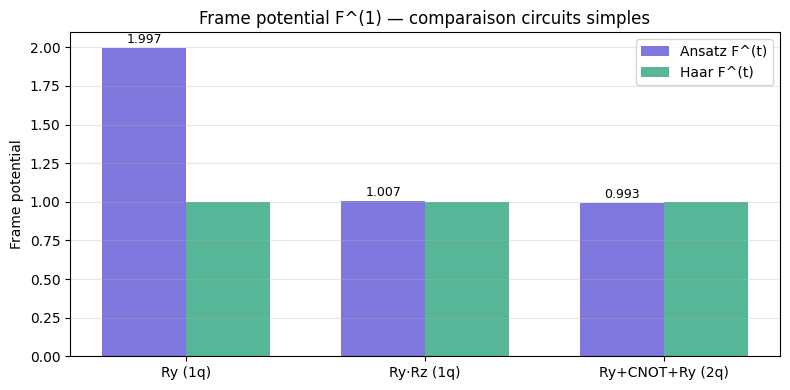

In [11]:
labels  = ['Ry (1q)', 'Ry·Rz (1q)', 'Ry+CNOT+Ry (2q)']
F_vals  = [result_ry['frame_potential'],
           result_ryrz['frame_potential'],
           result_2q['frame_potential']]
F_haars = [result_ry['haar_value'],
           result_ryrz['haar_value'],
           result_2q['haar_value']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, F_vals,  width, label='Ansatz F^(t)', color='#7f77dd')
bars2 = ax.bar(x + width/2, F_haars, width, label='Haar F^(t)',   color='#1d9e75', alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Frame potential')
ax.set_title(f'Frame potential F^({T_ORDER}) — comparaison circuits simples')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 — Sweep sur t : comment F^(t) évolue avec l'ordre du design ?

=== Circuit Ry·Rz (1 qubit) ===


Sampling unitaries: 100%|██████████| 300/300 [00:00<00:00, 3263.47it/s]


   t         F^(t)      F_Haar            ΔF     Ratio
──────────────────────────────────────────────────────
   1        1.0073      1.0000        0.0073     1.007
   2        2.2789      2.0000        0.2789     1.139
   3        6.3524      6.0000        0.3524     1.059



/home/tardant/Bureau/Qiskit/architectures/Frame potential/notebooks/../frame_potential.py:313: UserWarning: d=2 < 2t=4: large-d approximation may be inaccurate. Use --haar_mc for a Monte Carlo Haar estimate.
  F_haar = haar_frame_potential(t, d)
/home/tardant/Bureau/Qiskit/architectures/Frame potential/notebooks/../frame_potential.py:313: UserWarning: d=2 < 2t=6: large-d approximation may be inaccurate. Use --haar_mc for a Monte Carlo Haar estimate.
  F_haar = haar_frame_potential(t, d)
/home/tardant/Bureau/Qiskit/architectures/Frame potential/notebooks/../frame_potential.py:313: UserWarning: d=2 < 2t=8: large-d approximation may be inaccurate. Use --haar_mc for a Monte Carlo Haar estimate.
  F_haar = haar_frame_potential(t, d)


   4       19.4988     24.0000       -4.5012     0.812
──────────────────────────────────────────────────────


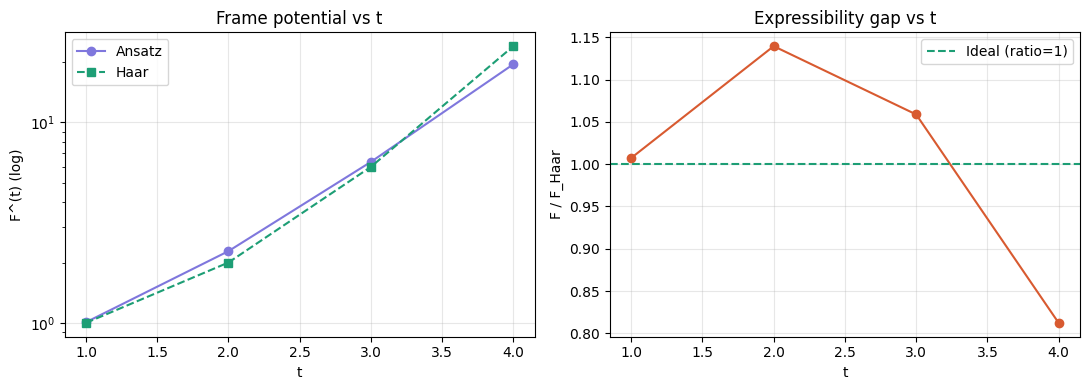

In [12]:
T_VALUES = [1, 2, 3, 4]

print("=== Circuit Ry·Rz (1 qubit) ===")
results_sweep = sweep_t(qc_ryrz, T_VALUES, n_samples=N_SAMPLES, seed=SEED)

ts      = [r['t']                for r in results_sweep]
Fs      = [r['frame_potential']  for r in results_sweep]
F_haars = [r['haar_value']       for r in results_sweep]
ratios  = [r['ratio']            for r in results_sweep]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gauche : F^(t) en log
axes[0].semilogy(ts, Fs,      'o-', label='Ansatz', color='#7f77dd')
axes[0].semilogy(ts, F_haars, 's--', label='Haar',  color='#1d9e75')
axes[0].set_xlabel('t')
axes[0].set_ylabel('F^(t) (log)')
axes[0].set_title('Frame potential vs t')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Droite : ratio F/F_Haar
axes[1].plot(ts, ratios, 'o-', color='#d85a30')
axes[1].axhline(1.0, color='#1d9e75', linestyle='--', label='Ideal (ratio=1)')
axes[1].set_xlabel('t')
axes[1].set_ylabel('F / F_Haar')
axes[1].set_title('Expressibility gap vs t')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7 — Convergence MC : F^(t) en fonction du nombre d'échantillons N

On vérifie que l'estimateur converge bien en $O(1/\sqrt{N})$.

N=  10  →  F^(1) = 1.02001
N=  50  →  F^(1) = 1.00340
N= 100  →  F^(1) = 0.99664
N= 200  →  F^(1) = 0.99771
N= 400  →  F^(1) = 1.00085


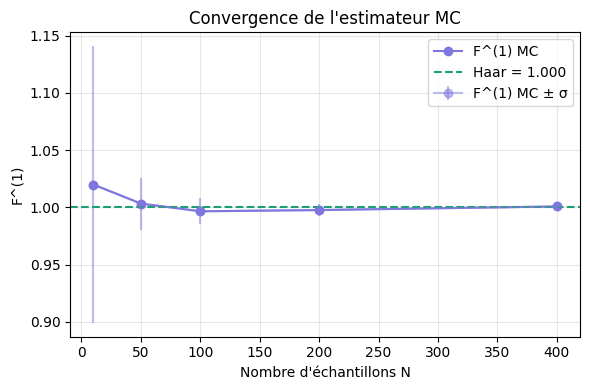

In [13]:
from frame_potential import sample_unitaries, frame_potential as fp

N_list = [10,50, 100, 200, 400]
F_convergence = []
Fidelity = []

rng = np.random.default_rng()
# Pré-tirage du plus grand pool, sous-sampler pour chaque N
Us_all_A = sample_unitaries(qc_ryrz, max(N_list), rng=rng, verbose=False)
Us_all_B = sample_unitaries(qc_ryrz, max(N_list), rng=rng, verbose=False)


for N in N_list:
    result = fp(Us_all_A[:N], Us_all_B[:N], t=1)
    F_n = result["frame_potential"]
    E_n = result["fidelity_error"]
    F_convergence.append(F_n)
    Fidelity.append(E_n)
    print(f"N={N:4d}  →  F^(1) = {F_n:.5f}")

F_haar_ref = haar_frame_potential(1, 2)

plt.figure(figsize=(6, 4))
plt.plot(N_list, F_convergence, 'o-', color='#7f77dd', label='F^(1) MC')
plt.errorbar(N_list, F_convergence, yerr=Fidelity, fmt='o-', color='#7f77dd', alpha=0.5, label='F^(1) MC ± σ')
plt.axhline(F_haar_ref, color='#1d9e75', linestyle='--', label=f'Haar = {F_haar_ref:.3f}')
plt.xlabel('Nombre d\'échantillons N')
plt.ylabel('F^(1)')
plt.title('Convergence de l\'estimateur MC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Récapitulatif

| Circuit | Qubits | Paramètres | F^(1) | F_Haar^(1) | Ratio |
|---------|--------|-----------|-------|-----------|-------|
| Ry | 1 | 1 | — | 1.0 | — |
| Ry·Rz | 1 | 2 | — | 1.0 | — |
| Ry+CNOT+Ry | 2 | 4 | — | 1.0 | — |

> **Interprétation** : plus le ratio $F^{(t)} / F_\mathrm{Haar}^{(t)}$ est proche de 1, plus l'ansatz est expressif au sens du t-design.

In [14]:
# Remplissage automatique du tableau récap
circuits = [
    ('Ry',             qc_ry,   result_ry),
    ('Ry·Rz',          qc_ryrz, result_ryrz),
    ('Ry+CNOT+Ry',     qc_2q,   result_2q),
]

print(f"{'Circuit':<18} {'Qubits':>6} {'Params':>7} {'F^(1)':>10} {'F_Haar':>8} {'Ratio':>7}")
print('─' * 62)
for name, qc, res in circuits:
    print(f"{name:<18} {qc.num_qubits:>6} {qc.num_parameters:>7}"
          f" {res['frame_potential']:>10.5f} {res['haar_value']:>8.5f} {res['ratio']:>7.3f}")

Circuit            Qubits  Params      F^(1)   F_Haar   Ratio
──────────────────────────────────────────────────────────────
Ry                      1       1    1.99699  1.00000   1.997
Ry·Rz                   1       2    1.00734  1.00000   1.007
Ry+CNOT+Ry              2       4    0.99349  1.00000   0.993


---
## 7 — Incressing the number of qubits

It is now time to incress the number of qubits and to see how the differetns architectures react to this incress

In [15]:
#circuits architectures names 
Name = [ "two_local_rx", "ghz_like", "brickwall"]
Colors = [ "#1d9e75", "#ff7f0e", "#d62728"]

In [16]:
def circuit_type_try(name : str, n_qubits : int, reps : int = 1, t : int = T_ORDER,n_samples : int = N_SAMPLES) -> QuantumCircuit:
    """Generate circuit of given type, with error handling.
    Then calculate its frame potential and return the result."""
    try:
        qc = build_ansatz(name, n_qubits, reps)

        result = compute_frame_potential(
            qc,
            t=t,
            n_samples=n_samples,
            verbose = False
        )
        return result
    except Exception as e:
        print(f"Error occurred while computing frame potential for circuit '{name}': {e}")
        return None

In [17]:
# ── Cell 0: verify the installation ──────────────────────────────────────────
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"xpu available  : {torch.xpu.is_available()}")

if torch.xpu.is_available():
    props = torch.xpu.get_device_properties(0)
    print(f"GPU             : {props.name}")
    print(f"VRAM            : {props.total_memory / 1024**3:.1f} GB")
    print(f"xpu version    : {torch.version.xpu}")
else:
    print("No GPU detected — all cells will run on CPU (correct but slow)")

import time

PyTorch version : 2.11.0+xpu
xpu available  : True
GPU             : Intel(R) Iris(R) Xe Graphics
VRAM            : 28.7 GB
xpu version    : 20250302


/home/tardant/Bureau/Qiskit/.venv/lib/python3.12/site-packages/torch/xpu/__init__.py:68: UserWarning: The detected GPU (Intel(R) Iris(R) Xe Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://github.com/pytorch/pytorch/blob/main/docs/source/notes/get_start_xpu.rst#hardware-prerequisite (Triggered internally at /pytorch/c10/xpu/XPUFunctions.cpp:128.)
  return torch._C._xpu_getDeviceCount()


In [18]:
from frame_potential_gpu import compute_frame_potential_gpu

def circuit_type_try_gpu(name : str, n_qubits : int, reps : int = 1, t : int = T_ORDER,n_samples : int = N_SAMPLES) -> QuantumCircuit:
    """Generate circuit of given type, with error handling.
    Then calculate its frame potential and return the result.
    This version uses GPU acceleration for the frame potential computation.
    It is only worth the overhead over a few n_qubits and large N_samples."""
    try:
        qc = build_ansatz(name, n_qubits, reps)
        result = compute_frame_potential_gpu(
            qc,
            t=t,
            dtype = torch.complex64,
            n_samples=n_samples,
            verbose = False
        )
        return result
    except Exception as e:
        print(f"Error occurred while computing frame potential for circuit '{name}': {e}")
        return None

/home/tardant/Bureau/Qiskit/architectures/Frame potential/notebooks/../frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


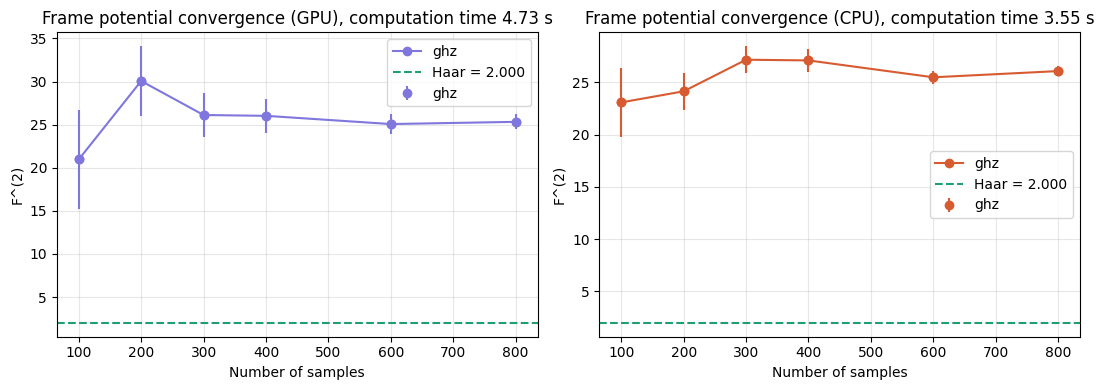

In [19]:
# Plot the convergence of F^(1) with incressing number of samples for a GHZ-like circuit, with error bars for variance
t=2
n_qubits = 4

N_list = [100,200,300,400,600,800]
F_gpu = []
error_gpu = []
Haar = haar_frame_potential(t, 2**n_qubits)

t0 = time.perf_counter()

for N in N_list:
    result_gpu = circuit_type_try_gpu("ghz_like", n_qubits, reps=1, t = t, n_samples=N)
    F_gpu.append(result_gpu["frame_potential"])
    error_gpu.append(result_gpu["fidelity_error"])

time_gpu = time.perf_counter() - t0
t0 = time.perf_counter()



F_cpu = []
error_cpu = []

for N in N_list:
    result_cpu = circuit_type_try("ghz_like", n_qubits, reps=1, t = t, n_samples=N)
    F_cpu.append(result_cpu["frame_potential"])
    error_cpu.append(result_cpu["fidelity_error"])

time_cpu = time.perf_counter() - t0
    
# Plot convergence of F^(1) computed on cpu and gpu on 2 figures with repetitions with error bars
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(N_list, F_gpu, 'o-', color='#7f77dd', label='ghz')
axes[0].errorbar(N_list, F_gpu, yerr=error_gpu, fmt='o', color='#7f77dd', label='ghz')
axes[0].axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel(f'F^({t})')
axes[0].set_title(f'Frame potential convergence (GPU), computation time {time_gpu:.2f} s')

axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(N_list, F_cpu, 'o-', color='#d85a30', label='ghz')
axes[1].errorbar(N_list, F_cpu, yerr=error_cpu, fmt='o', color='#d85a30', label='ghz')
axes[1].axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel(f'F^({t})')
axes[1].set_title(f'Frame potential convergence (CPU), computation time {time_cpu:.2f} s')

axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()


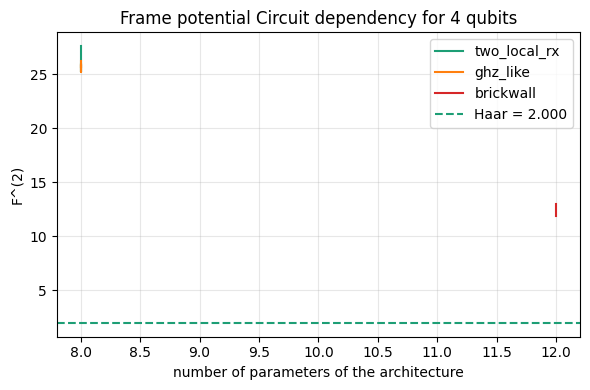

In [24]:
# Plot F^(2) using differents achitectures with error bars for variance
# for each circuit try different repetitions and plot the convergence of F^(2) with repetitions for each circuit, with error bars for variance

n_qubits = 4
reps = [1, 2, 3, 4, 5]
t = 2
N = 500
plt.figure(figsize=(6, 4))



Haar = haar_frame_potential(t, 2**n_qubits)


for name,color in zip(Name,Colors):
    F = []
    n_param = []
    for r in reps:
        result = circuit_type_try_gpu(name, n_qubits, reps=r, t = t, n_samples=N)
        F.append(result["frame_potential"])
        n_param.append(result["n_parameters"])
    plt.plot(n_param, F, color=color, label=name)


    
# Plot convergence of F^(1) with repetitions with error bars for variance
plt.axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
plt.xlabel('number of parameters of the architecture')
plt.ylabel(f'F^({t})')
plt.title('Frame potential Circuit dependency for 4 qubits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [21]:
# comparaision circulkaire lineaire



GPU computation time: 7.59 s


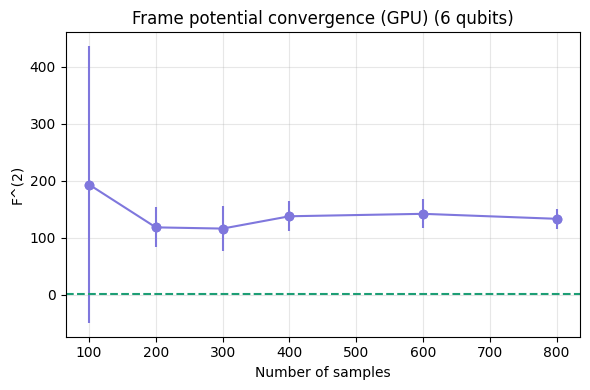

In [22]:
# Plot the convergence of F^(2) with incressing number of samples for a GHZ-like circuit, with error bars for variance
t=2
n_qubits = 6

N_list = [100,200,300,400,600,800]
F_gpu = []
error_gpu = []
Haar = haar_frame_potential(t, 2**n_qubits)

t0 = time.perf_counter()

for N in N_list:
    result_gpu = circuit_type_try_gpu("ghz_like", n_qubits, reps=3, t = t, n_samples=N)
    F_gpu.append(result_gpu["frame_potential"])
    error_gpu.append(result_gpu["fidelity_error"])

time_gpu = time.perf_counter() - t0
t0 = time.perf_counter()

    
# Plot convergence of F^(1) computed on cpu and gpu on 2 figures with repetitions with error bars
plt.figure(figsize=(6, 4))

plt.plot(N_list, F_gpu, 'o-', color='#7f77dd', label='ghz')
plt.errorbar(N_list, F_gpu, yerr=error_gpu, fmt='o', color='#7f77dd', label='ghz')
plt.axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
plt.xlabel('Number of samples')
plt.ylabel(f'F^({t})')
plt.title(f'Frame potential convergence (GPU) (6 qubits)')

axes[0].legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

print(f"GPU computation time: {time_gpu:.2f} s")


<Figure size 600x400 with 0 Axes>

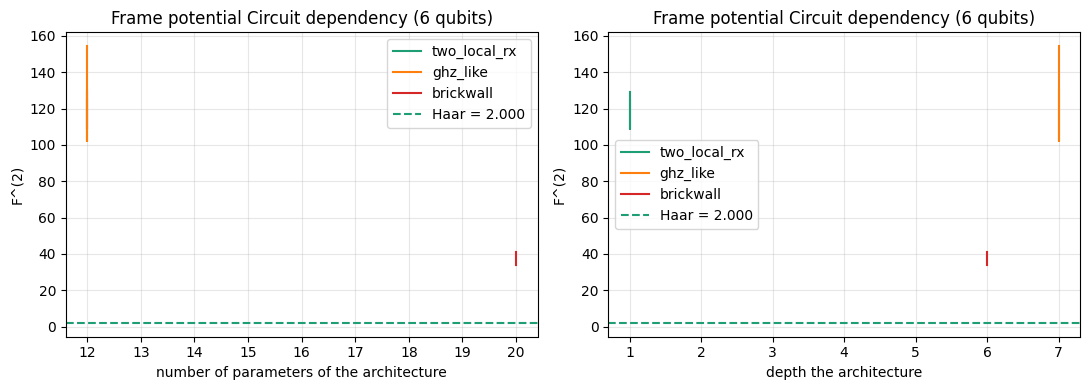

In [23]:
# Plot F^(2) using differents achitectures with error bars for variance
# for each circuit try different repetitions and plot the convergence of F^(2) with repetitions for each circuit, with error bars for variance

n_qubits = 6
reps = [2, 4, 6]
t = 2
N = 400
plt.figure(figsize=(6, 4))



Haar = haar_frame_potential(t, 2**n_qubits)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name,color in zip(Name,Colors):
    F = []
    n_param = []
    depth = []
    for r in reps:
        result = circuit_type_try_gpu(name, n_qubits, reps=r, t = t, n_samples=N)
        F.append(result["frame_potential"])
        n_param.append(result["n_parameters"])
        depth.append(result["circuit_depth"])
    axes[0].plot(n_param, F, color=color, label=name)
    axes[1].plot(depth, F, color=color, label=name)


    
# Plot convergence of F^(1) with repetitions with error bars for variance
axes[0].axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
axes[0].set_xlabel('number of parameters of the architecture')
axes[0].set_ylabel(f'F^({t})')
axes[0].set_title('Frame potential Circuit dependency (6 qubits)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].axhline(Haar, color='#1d9e75', linestyle='--', label=f'Haar = {Haar:.3f}')
axes[1].set_xlabel('depth the architecture')
axes[1].set_ylabel(f'F^({t})')
axes[1].set_title('Frame potential Circuit dependency (6 qubits)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()